# **ENCUESTAS DEL DESEMPEÑO ACADÉMICO DE LOS DOCENTES**

##ENUNCIADO DEL PROBLEMA

Se desea identificar la importancia relativa de cada una de las preguntas de la encuesta aplicada a los estudiantes de la Universidad Nacional de San Antonio Abad del Cusco (UNSAAC), con el fin de determinar qué aspectos del desempeño docente tienen mayor influencia en la percepción global de su rendimiento.

Contexto:
Cada semestre, los estudiantes completan una encuesta compuesta por 20 preguntas, cada una con respuesta en escala de 0 a 10, relacionadas con distintos aspectos del desempeño docente (Tal como se muestra en la figura). Adicionalmente, se obtiene un puntaje global asignado al docente por los estudiantes, que sirve como variable objetivo.



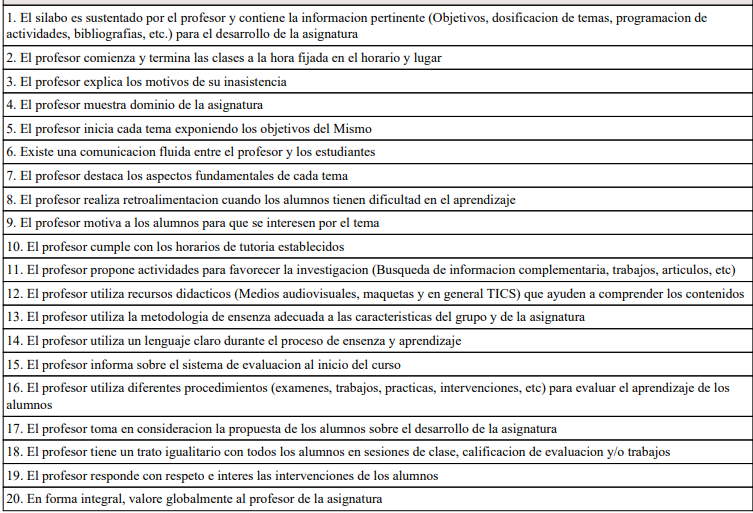

**Problema a resolver con aprendizaje automático**

Se plantea el problema como una tarea de clasificación supervisada; Utilizando un modelo de tipo Random Forest Classifier, se busca determinar la importancia relativa (feature importance) de cada una de las preguntas, con el fin de identificar cuáles son las que más contribuyen a explicar las variaciones en el puntaje global.

Meta del estudio:

Evaluar la influencia individual de cada pregunta.

Priorizar los aspectos del desempeño docente que más inciden en la percepción de los estudiantes.

Optimizar el contenido de la encuesta en futuras aplicaciones, enfocándose en los ítems más representativos.

## **1. IMPORTAR LIBRERÍAS**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

## **2. CARGAR Y LEER DATA**

In [ ]:
df = pd.read_csv('encuestas.csv', encoding='latin1')

In [ ]:
# -- Mostrar número de filas y columnas
df.shape

(226301, 22)

In [ ]:
# -- Mostrar los datos de las primeras filas
df.head()

,Unnamed: 0,P01,P02,P03,P04,P05,P06,P07,P08,P09,...,P12,P13,P14,P15,P16,P17,P18,P19,P20,Puntaje
0,0,10,10,10,10,10,10,10,10,10,...,9,9,9,9,9,9,9,9,9,9.45
1,1,6,6,6,6,6,6,6,6,5,...,6,6,5,6,6,5,6,5,6,5.80
2,2,9,9,9,9,9,9,9,9,9,...,9,9,9,9,9,9,9,9,9,9.00
3,3,9,9,9,8,10,10,8,8,10,...,7,9,10,10,8,9,10,8,10,9.00
4,4,7,8,8,8,7,7,7,7,8,...,6,7,6,6,6,6,7,6,6,6.85


## **3. PREPROCESAMIENTO DE DATOS:**

In [ ]:
# -- Verificar que todos los datos sean numéricos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226301 entries, 0 to 226300
Data columns (total 22 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Unnamed: 0  226301 non-null  int64  
 1   P01         226301 non-null  int64  
 2   P02         226301 non-null  int64  
 3   P03         226301 non-null  int64  
 4   P04         226301 non-null  int64  
 5   P05         226301 non-null  int64  
 6   P06         226301 non-null  int64  
 7   P07         226301 non-null  int64  
 8   P08         226301 non-null  int64  
 9   P09         226301 non-null  int64  
 10  P10         226301 non-null  int64  
 11  P11         226301 non-null  int64  
 12  P12         226301 non-null  int64  
 13  P13         226301 non-null  int64  
 14  P14         226301 non-null  int64  
 15  P15         226301 non-null  int64  
 16  P16         226301 non-null  int64  
 17  P17         226301 non-null  int64  
 18  P18         226301 non-null  int64  
 19  P1

### FUNCIONES PARA DISCRETIZAR DATOS

In [ ]:
def transformar_puntaje(Puntaje):
    if Puntaje >= 9:
        return 4
    elif 8 <= Puntaje < 9:
        return 3
    elif 6 <= Puntaje < 8:
        return 2
    elif 5 <= Puntaje < 6:
        return 1
    else:
        return 0

### SELECCIONAR SOLO COLUMNAS REQUERIDAS

In [ ]:
df.head()

,Unnamed: 0,P01,P02,P03,P04,P05,P06,P07,P08,P09,...,P12,P13,P14,P15,P16,P17,P18,P19,P20,Puntaje
0,0,10,10,10,10,10,10,10,10,10,...,9,9,9,9,9,9,9,9,9,9.45
1,1,6,6,6,6,6,6,6,6,5,...,6,6,5,6,6,5,6,5,6,5.80
2,2,9,9,9,9,9,9,9,9,9,...,9,9,9,9,9,9,9,9,9,9.00
3,3,9,9,9,8,10,10,8,8,10,...,7,9,10,10,8,9,10,8,10,9.00
4,4,7,8,8,8,7,7,7,7,8,...,6,7,6,6,6,6,7,6,6,6.85


In [ ]:
df['PuntajeFinal'] = df['Puntaje'].apply(transformar_puntaje)
df_final = df[['P01', 'P02', 'P03', 'P04', 'P05', 'P06', 'P07', 'P08', 'P09', 'P10',
               'P11', 'P12', 'P13', 'P14', 'P15', 'P16', 'P17', 'P18', 'P19', 'P20', 'PuntajeFinal']]

In [ ]:
df_final.head()

,P01,P02,P03,P04,P05,P06,P07,P08,P09,P10,...,P12,P13,P14,P15,P16,P17,P18,P19,P20,PuntajeFinal
0,10,10,10,10,10,10,10,10,10,9,...,9,9,9,9,9,9,9,9,9,4
1,6,6,6,6,6,6,6,6,5,6,...,6,6,5,6,6,5,6,5,6,1
2,9,9,9,9,9,9,9,9,9,9,...,9,9,9,9,9,9,9,9,9,4
3,9,9,9,8,10,10,8,8,10,10,...,7,9,10,10,8,9,10,8,10,4
4,7,8,8,8,7,7,7,7,8,7,...,6,7,6,6,6,6,7,6,6,2


## **4. ELEGIR EL MODELO: RANDOM FOREST**

In [ ]:
# -- Elegir el modelo Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=30)

## **5. ENTRENAR EL MODELO**

###Separar los datos en variables X, y

In [ ]:
# -- Obtener una copia de los datos
datos =  df_final
# Dividir los datos en características (X) y la variable objetivo (y)
X = datos.drop('PuntajeFinal', axis=1)
y = datos['PuntajeFinal']

###Dividir los datos en datos de Entrenamiento y datos de Test

In [ ]:
# Dividir los datos en conjunto de entrenamiento y conjunto de prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=30)

###Entrenar el modelo

In [ ]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=30)

## **6. EVALUAR EL MODELO**

In [ ]:
# Calcular la precisión del modelo
y_pred = rf_model.predict(X_test)
precision = accuracy_score(y_test, y_pred)
print("Precisión del modelo:", precision)

Precisión del modelo: 0.9798943903139569


## **7. OBTENER LAS CARACTERÍSTICAS MÁS IMPORTANTES**

In [ ]:
importancias = rf_model.feature_importances_
caracteristicas = X.columns

## **8. MOSTRAR RESULTADOS**

###En forma de Tabla

In [ ]:
importancia_df = pd.DataFrame({'Característica': caracteristicas, 'Importancia': importancias})
importancia_df = importancia_df.sort_values(by='Importancia', ascending=False)
print(importancia_df)

   Característica  Importancia
13            P14     0.104397
12            P13     0.100048
8             P09     0.088365
7             P08     0.076001
6             P07     0.061652
11            P12     0.059174
5             P06     0.057855
16            P17     0.050523
4             P05     0.048691
19            P20     0.047164
10            P11     0.044978
15            P16     0.038954
1             P02     0.035937
2             P03     0.032943
14            P15     0.032133
18            P19     0.026623
3             P04     0.025765
17            P18     0.023635
0             P01     0.023009
9             P10     0.022155


###En forma de Gráfico

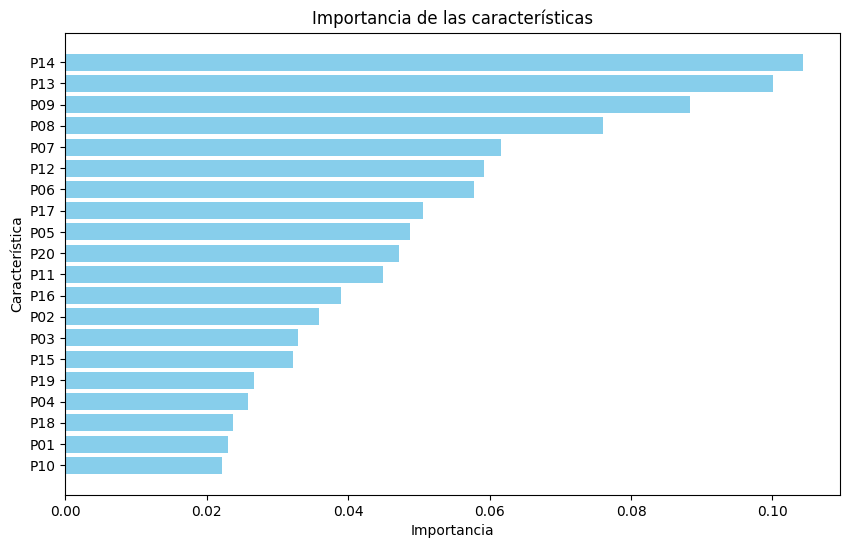

In [ ]:
# Graficar
plt.figure(figsize=(10, 6))
plt.barh(importancia_df['Característica'], importancia_df['Importancia'], color='skyblue')
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.title('Importancia de las características')
plt.gca().invert_yaxis()
plt.show()

---

## **9. ¿CUÁNTAS PREGUNTAS SON REALMENTE NECESARIAS?**

La importancia individual no responde directamente la pregunta de "¿con cuántas preguntas basta?". Para responderla aplicamos tres estrategias complementarias:

1. **Importancia acumulada** — ordenamos las preguntas por importancia y vemos cuántas se necesitan para cubrir el 80%, 90% y 95% del total.
2. **Selección incremental Top-K** — re-entrenamos el modelo usando solo las K preguntas más importantes (K = 1, 2, …, 20) y medimos la precisión. Buscamos el codo donde añadir más preguntas ya no mejora.
3. **RFECV (Recursive Feature Elimination with Cross-Validation)** — sklearn elimina iterativamente la peor pregunta y valida con CV; encuentra de forma automática el subconjunto óptimo.

Adicionalmente usamos **permutation importance** como verificación robusta del ranking.

### 9.1 Importancia acumulada

In [ ]:
# Importancia acumulada de las preguntas (ya ordenadas en importancia_df)
importancia_df = importancia_df.reset_index(drop=True)
importancia_df['Importancia_acumulada'] = importancia_df['Importancia'].cumsum()

# Cuantas preguntas se necesitan para cubrir 80 / 90 / 95 % de la importancia total
def k_para_cubrir(pct):
    return int((importancia_df['Importancia_acumulada'] >= pct).idxmax()) + 1

k80 = k_para_cubrir(0.80)
k90 = k_para_cubrir(0.90)
k95 = k_para_cubrir(0.95)

print(f'Para cubrir el 80% de la importancia se necesitan: {k80} preguntas')
print(f'Para cubrir el 90% de la importancia se necesitan: {k90} preguntas')
print(f'Para cubrir el 95% de la importancia se necesitan: {k95} preguntas')

print('\nRanking con importancia acumulada:')
print(importancia_df.to_string(index=False))

# Grafico de la importancia acumulada
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(importancia_df) + 1),
         importancia_df['Importancia_acumulada'] * 100,
         marker='o', color='steelblue')
plt.axhline(80, color='orange', linestyle='--', label='80%')
plt.axhline(90, color='red', linestyle='--', label='90%')
plt.axhline(95, color='green', linestyle='--', label='95%')
plt.xlabel('Numero de preguntas (Top-K)')
plt.ylabel('Importancia acumulada (%)')
plt.title('Importancia acumulada por numero de preguntas')
plt.xticks(range(1, len(importancia_df) + 1))
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


### 9.2 Selección incremental Top-K (precisión vs. número de preguntas)

In [ ]:
# Re-entrenamos el modelo usando solo las K preguntas mas importantes
# y medimos la precision sobre el mismo X_test/y_test.

ranking = importancia_df['Característica'].tolist()
resultados_k = []

for k in range(1, len(ranking) + 1):
    top_k = ranking[:k]
    modelo_k = RandomForestClassifier(n_estimators=100, random_state=30, n_jobs=-1)
    modelo_k.fit(X_train[top_k], y_train)
    pred_k = modelo_k.predict(X_test[top_k])
    acc_k = accuracy_score(y_test, pred_k)
    resultados_k.append({'K': k, 'preguntas': top_k, 'precision': acc_k})
    print(f'K={k:2d}  precision={acc_k:.4f}  ({top_k[-1]} agregada)')

resultados_df = pd.DataFrame(resultados_k)

# Grafico K vs precision
plt.figure(figsize=(10, 5))
plt.plot(resultados_df['K'], resultados_df['precision'], marker='o', color='darkgreen')
plt.axhline(precision, color='red', linestyle='--',
            label=f'Precision con las 20 preguntas: {precision:.4f}')
plt.xlabel('Numero de preguntas usadas (Top-K)')
plt.ylabel('Precision en test')
plt.title('Precision del modelo segun numero de preguntas')
plt.xticks(range(1, len(ranking) + 1))
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Identificar el K minimo que alcanza al menos el 99% de la precision total
umbral = 0.99 * precision
k_minimo = int(resultados_df.loc[resultados_df['precision'] >= umbral, 'K'].min())
print(f'\nK minimo que alcanza >= 99% de la precision total ({precision:.4f}): {k_minimo}')
print(f'Preguntas seleccionadas: {ranking[:k_minimo]}')


### 9.3 RFECV — búsqueda automática del K óptimo

In [ ]:
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold

# Para que RFECV no tarde demasiado con 226k filas, usamos una sub-muestra estratificada
muestra_n = min(20000, len(X_train))
idx = X_train.sample(n=muestra_n, random_state=30).index
X_sub, y_sub = X_train.loc[idx], y_train.loc[idx]

estimator = RandomForestClassifier(n_estimators=100, random_state=30, n_jobs=-1)
rfecv = RFECV(
    estimator=estimator,
    step=1,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=30),
    scoring='accuracy',
    min_features_to_select=1,
    n_jobs=-1,
)
rfecv.fit(X_sub, y_sub)

print(f'Numero optimo de preguntas segun RFECV: {rfecv.n_features_}')
seleccionadas = X.columns[rfecv.support_].tolist()
print(f'Preguntas seleccionadas: {seleccionadas}')

# Curva CV
scores = rfecv.cv_results_['mean_test_score']
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(scores) + 1), scores, marker='o', color='purple')
plt.xlabel('Numero de preguntas usadas')
plt.ylabel('Precision media (CV 5-fold)')
plt.title('RFECV: precision por tamano del subconjunto')
plt.xticks(range(1, len(scores) + 1))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 9.4 Validación con Permutation Importance (más robusto que feature_importances_)

In [ ]:
from sklearn.inspection import permutation_importance

# Permutation importance se calcula sobre test con el modelo ya entrenado.
# Para acelerar, usamos una sub-muestra del test.
test_idx = X_test.sample(n=min(10000, len(X_test)), random_state=30).index
result = permutation_importance(
    rf_model, X_test.loc[test_idx], y_test.loc[test_idx],
    n_repeats=5, random_state=30, n_jobs=-1, scoring='accuracy'
)

perm_df = pd.DataFrame({
    'Característica': X.columns,
    'Importancia_perm_media': result.importances_mean,
    'Importancia_perm_std':   result.importances_std,
}).sort_values('Importancia_perm_media', ascending=False).reset_index(drop=True)

print('Permutation importance:')
print(perm_df.to_string(index=False))

# Comparar el ranking de feature_importances_ vs permutation
comparativa = pd.merge(
    importancia_df[['Característica', 'Importancia']].rename(columns={'Importancia': 'Imp_Gini'}),
    perm_df[['Característica', 'Importancia_perm_media']],
    on='Característica'
)
comparativa['Rank_Gini'] = comparativa['Imp_Gini'].rank(ascending=False).astype(int)
comparativa['Rank_Perm'] = comparativa['Importancia_perm_media'].rank(ascending=False).astype(int)
print('\nComparativa de rankings:')
print(comparativa.sort_values('Rank_Gini').to_string(index=False))


### 9.5 Conclusión final

In [ ]:
print('=' * 65)
print(' RESUMEN: ¿CUANTAS PREGUNTAS SON REALMENTE NECESARIAS?')
print('=' * 65)

print(f'\nPrecision usando las 20 preguntas:           {precision:.4f}')

print('\n[Estrategia 1] Importancia acumulada')
print(f'  - 80 % de la importancia: {k80} preguntas')
print(f'  - 90 % de la importancia: {k90} preguntas')
print(f'  - 95 % de la importancia: {k95} preguntas')

print('\n[Estrategia 2] Top-K incremental (umbral: >= 99% de la precision total)')
print(f'  - Minimo K necesario: {k_minimo} preguntas')
print(f'  - Preguntas elegidas: {ranking[:k_minimo]}')

print('\n[Estrategia 3] RFECV (validacion cruzada 5-fold)')
print(f'  - K optimo: {rfecv.n_features_} preguntas')
print(f'  - Preguntas elegidas: {seleccionadas}')

print('\n[Recomendacion]')
recomendado = sorted(set(ranking[:k_minimo]) | set(seleccionadas))
print(f'  - Conjunto recomendado (union Top-K + RFECV): {len(recomendado)} preguntas')
print(f'    {recomendado}')
interseccion = sorted(set(ranking[:k_minimo]) & set(seleccionadas))
print(f'  - Conjunto minimo defendible (interseccion): {len(interseccion)} preguntas')
print(f'    {interseccion}')


### Cómo interpretar los tres resultados

- **Importancia acumulada** dice cuántas preguntas concentran la "señal", pero no garantiza que el modelo prediga igual de bien con menos.
- **Top-K incremental** mide directamente el impacto en precisión y suele ser el más práctico para decidir un corte: el K mínimo que mantiene ≥ 99 % de la precisión total es el "número defendible" de preguntas.
- **RFECV** valida con cross-validation y resiste mejor a sobreajuste; suele coincidir con el codo del Top-K.

**Regla general:** si las tres estrategias coinciden alrededor de un mismo K (típicamente entre 8 y 14 preguntas en encuestas de 20 ítems), ese K es un buen candidato para una versión reducida de la encuesta. Si difieren, conviene quedarse con la **unión** de los conjuntos para no perder señal o con la **intersección** si se quiere maximizar la reducción.

---

## **9. ¿CUÁNTAS PREGUNTAS SON REALMENTE NECESARIAS?**

La importancia individual no responde directamente la pregunta de "¿con cuántas preguntas basta?". Para responderla aplicamos tres estrategias complementarias:

1. **Importancia acumulada** — ordenamos las preguntas por importancia y vemos cuántas se necesitan para cubrir el 80%, 90% y 95% del total.
2. **Selección incremental Top-K** — re-entrenamos el modelo usando solo las K preguntas más importantes (K = 1, 2, …, 20) y medimos la precisión. Buscamos el codo donde añadir más preguntas ya no mejora.
3. **RFECV (Recursive Feature Elimination with Cross-Validation)** — sklearn elimina iterativamente la peor pregunta y valida con CV; encuentra de forma automática el subconjunto óptimo.

Adicionalmente usamos **permutation importance** como verificación robusta del ranking.

### 9.1 Importancia acumulada

In [ ]:
# Importancia acumulada de las preguntas (ya ordenadas en importancia_df)
importancia_df = importancia_df.reset_index(drop=True)
importancia_df['Importancia_acumulada'] = importancia_df['Importancia'].cumsum()

# Cuantas preguntas se necesitan para cubrir 80 / 90 / 95 % de la importancia total
def k_para_cubrir(pct):
    return int((importancia_df['Importancia_acumulada'] >= pct).idxmax()) + 1

k80 = k_para_cubrir(0.80)
k90 = k_para_cubrir(0.90)
k95 = k_para_cubrir(0.95)

print(f'Para cubrir el 80% de la importancia se necesitan: {k80} preguntas')
print(f'Para cubrir el 90% de la importancia se necesitan: {k90} preguntas')
print(f'Para cubrir el 95% de la importancia se necesitan: {k95} preguntas')

print('\nRanking con importancia acumulada:')
print(importancia_df.to_string(index=False))

# Grafico de la importancia acumulada
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(importancia_df) + 1),
         importancia_df['Importancia_acumulada'] * 100,
         marker='o', color='steelblue')
plt.axhline(80, color='orange', linestyle='--', label='80%')
plt.axhline(90, color='red', linestyle='--', label='90%')
plt.axhline(95, color='green', linestyle='--', label='95%')
plt.xlabel('Numero de preguntas (Top-K)')
plt.ylabel('Importancia acumulada (%)')
plt.title('Importancia acumulada por numero de preguntas')
plt.xticks(range(1, len(importancia_df) + 1))
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


### 9.2 Selección incremental Top-K (precisión vs. número de preguntas)

In [ ]:
# Re-entrenamos el modelo usando solo las K preguntas mas importantes
# y medimos la precision sobre el mismo X_test/y_test.

ranking = importancia_df['Característica'].tolist()
resultados_k = []

for k in range(1, len(ranking) + 1):
    top_k = ranking[:k]
    modelo_k = RandomForestClassifier(n_estimators=100, random_state=30, n_jobs=-1)
    modelo_k.fit(X_train[top_k], y_train)
    pred_k = modelo_k.predict(X_test[top_k])
    acc_k = accuracy_score(y_test, pred_k)
    resultados_k.append({'K': k, 'preguntas': top_k, 'precision': acc_k})
    print(f'K={k:2d}  precision={acc_k:.4f}  ({top_k[-1]} agregada)')

resultados_df = pd.DataFrame(resultados_k)

# Grafico K vs precision
plt.figure(figsize=(10, 5))
plt.plot(resultados_df['K'], resultados_df['precision'], marker='o', color='darkgreen')
plt.axhline(precision, color='red', linestyle='--',
            label=f'Precision con las 20 preguntas: {precision:.4f}')
plt.xlabel('Numero de preguntas usadas (Top-K)')
plt.ylabel('Precision en test')
plt.title('Precision del modelo segun numero de preguntas')
plt.xticks(range(1, len(ranking) + 1))
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Identificar el K minimo que alcanza al menos el 99% de la precision total
umbral = 0.99 * precision
k_minimo = int(resultados_df.loc[resultados_df['precision'] >= umbral, 'K'].min())
print(f'\nK minimo que alcanza >= 99% de la precision total ({precision:.4f}): {k_minimo}')
print(f'Preguntas seleccionadas: {ranking[:k_minimo]}')


### 9.3 RFECV — búsqueda automática del K óptimo

In [ ]:
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold

# Para que RFECV no tarde demasiado con 226k filas, usamos una sub-muestra estratificada
muestra_n = min(20000, len(X_train))
idx = X_train.sample(n=muestra_n, random_state=30).index
X_sub, y_sub = X_train.loc[idx], y_train.loc[idx]

estimator = RandomForestClassifier(n_estimators=100, random_state=30, n_jobs=-1)
rfecv = RFECV(
    estimator=estimator,
    step=1,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=30),
    scoring='accuracy',
    min_features_to_select=1,
    n_jobs=-1,
)
rfecv.fit(X_sub, y_sub)

print(f'Numero optimo de preguntas segun RFECV: {rfecv.n_features_}')
seleccionadas = X.columns[rfecv.support_].tolist()
print(f'Preguntas seleccionadas: {seleccionadas}')

# Curva CV
scores = rfecv.cv_results_['mean_test_score']
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(scores) + 1), scores, marker='o', color='purple')
plt.xlabel('Numero de preguntas usadas')
plt.ylabel('Precision media (CV 5-fold)')
plt.title('RFECV: precision por tamano del subconjunto')
plt.xticks(range(1, len(scores) + 1))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 9.4 Validación con Permutation Importance (más robusto que feature_importances_)

In [ ]:
from sklearn.inspection import permutation_importance

# Permutation importance se calcula sobre test con el modelo ya entrenado.
# Para acelerar, usamos una sub-muestra del test.
test_idx = X_test.sample(n=min(10000, len(X_test)), random_state=30).index
result = permutation_importance(
    rf_model, X_test.loc[test_idx], y_test.loc[test_idx],
    n_repeats=5, random_state=30, n_jobs=-1, scoring='accuracy'
)

perm_df = pd.DataFrame({
    'Característica': X.columns,
    'Importancia_perm_media': result.importances_mean,
    'Importancia_perm_std':   result.importances_std,
}).sort_values('Importancia_perm_media', ascending=False).reset_index(drop=True)

print('Permutation importance:')
print(perm_df.to_string(index=False))

# Comparar el ranking de feature_importances_ vs permutation
comparativa = pd.merge(
    importancia_df[['Característica', 'Importancia']].rename(columns={'Importancia': 'Imp_Gini'}),
    perm_df[['Característica', 'Importancia_perm_media']],
    on='Característica'
)
comparativa['Rank_Gini'] = comparativa['Imp_Gini'].rank(ascending=False).astype(int)
comparativa['Rank_Perm'] = comparativa['Importancia_perm_media'].rank(ascending=False).astype(int)
print('\nComparativa de rankings:')
print(comparativa.sort_values('Rank_Gini').to_string(index=False))


### 9.5 Conclusión final

In [ ]:
print('=' * 65)
print(' RESUMEN: ¿CUANTAS PREGUNTAS SON REALMENTE NECESARIAS?')
print('=' * 65)

print(f'\nPrecision usando las 20 preguntas:           {precision:.4f}')

print('\n[Estrategia 1] Importancia acumulada')
print(f'  - 80 % de la importancia: {k80} preguntas')
print(f'  - 90 % de la importancia: {k90} preguntas')
print(f'  - 95 % de la importancia: {k95} preguntas')

print('\n[Estrategia 2] Top-K incremental (umbral: >= 99% de la precision total)')
print(f'  - Minimo K necesario: {k_minimo} preguntas')
print(f'  - Preguntas elegidas: {ranking[:k_minimo]}')

print('\n[Estrategia 3] RFECV (validacion cruzada 5-fold)')
print(f'  - K optimo: {rfecv.n_features_} preguntas')
print(f'  - Preguntas elegidas: {seleccionadas}')

print('\n[Recomendacion]')
recomendado = sorted(set(ranking[:k_minimo]) | set(seleccionadas))
print(f'  - Conjunto recomendado (union Top-K + RFECV): {len(recomendado)} preguntas')
print(f'    {recomendado}')
interseccion = sorted(set(ranking[:k_minimo]) & set(seleccionadas))
print(f'  - Conjunto minimo defendible (interseccion): {len(interseccion)} preguntas')
print(f'    {interseccion}')


### Cómo interpretar los tres resultados

- **Importancia acumulada** dice cuántas preguntas concentran la "señal", pero no garantiza que el modelo prediga igual de bien con menos.
- **Top-K incremental** mide directamente el impacto en precisión y suele ser el más práctico para decidir un corte: el K mínimo que mantiene ≥ 99 % de la precisión total es el "número defendible" de preguntas.
- **RFECV** valida con cross-validation y resiste mejor a sobreajuste; suele coincidir con el codo del Top-K.

**Regla general:** si las tres estrategias coinciden alrededor de un mismo K (típicamente entre 8 y 14 preguntas en encuestas de 20 ítems), ese K es un buen candidato para una versión reducida de la encuesta. Si difieren, conviene quedarse con la **unión** de los conjuntos para no perder señal o con la **intersección** si se quiere maximizar la reducción.